# Forecasting Exchange Rates using Time Series Analysis

## Objective
The objective of this study is to forecast future USD to Australian Dollar (USD/AUD) exchange rates using time series forecasting techniques, specifically ARIMA and Exponential Smoothing (ETS), based on historical data from the exchange_rate.csv dataset.

## Dataset Description
The dataset contains historical exchange rate data with:
* date: Date of observation
* Ex_rate: USD to Australian Dollar exchange rate

The date column is used as the time index for analysis.

### Importing Requred Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Part 1: Data Preparation and Exploration

### 1. Data Loading

In [2]:
df = pd.read_csv('exchange_rate.csv')

In [3]:
# Convert date column
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M')

In [4]:
# Set date as index
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

In [5]:
# Rename exchange rate column for clarity
df.rename(columns={'Ex_rate': 'USD_AUD'}, inplace=True)
df.head()

,USD_AUD
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [6]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   USD_AUD  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB


,USD_AUD
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


### 2. Initial Exploration

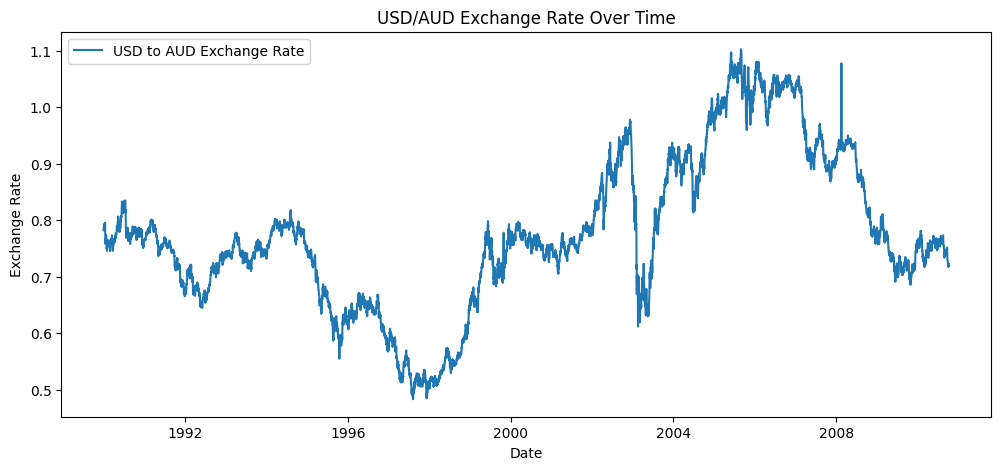

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(df['USD_AUD'], label='USD to AUD Exchange Rate')
plt.title('USD/AUD Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

### Interpretation

* The exchange rate exhibits clear long-term trends and high volatility.
* Sudden spikes and drops indicate possible economic or market shocks.
* No clear seasonal pattern is observed.

### Seasonal Decomposition

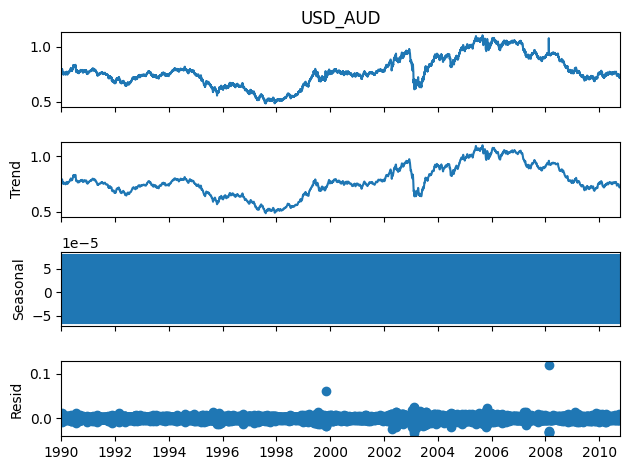

In [8]:
decompose = seasonal_decompose(df['USD_AUD'], model='additive', period=5)
decompose.plot()
plt.show()

### 3. Data Preprocessing

In [9]:
# Check for missing values
df.isnull().sum()

USD_AUD    0
dtype: int64

* No missing values were observed in the dataset; therefore, no imputation was required.

In [10]:
# Calculate Z-score
z_scores = np.abs((df['USD_AUD'] - df['USD_AUD'].mean()) / df['USD_AUD'].std())
# Threshold
threshold = 3
# Detect outliers
outliers_z = df[z_scores > threshold]

print("Number of Outliers (Z-score):", len(outliers_z))
print(outliers_z.head())

Number of Outliers (Z-score): 0
Empty DataFrame
Columns: [USD_AUD]
Index: []


* Z-score method detected no statistical outliers. The 2008 spike represents structural economic volatility rather than abnormal data error.

### Rolling Statistics (Stationarity Visual Check)

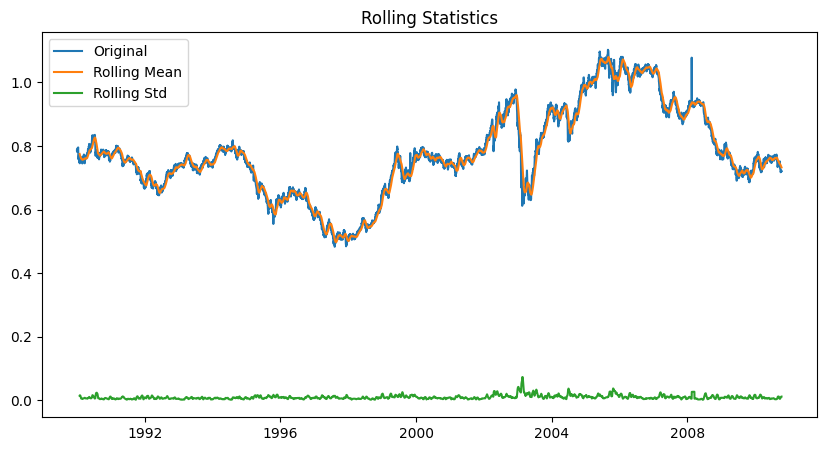

In [11]:
rolling_mean = df['USD_AUD'].rolling(window=30).mean()
rolling_std = df['USD_AUD'].rolling(window=30).std()

plt.figure(figsize=(10,5))
plt.plot(df['USD_AUD'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')
plt.legend()
plt.title('Rolling Statistics')
plt.show()

* Rolling mean and standard deviation were plotted to detect structural breaks or anomalies.
* A structural volatility spike was observed around 2008, corresponding to the global financial crisis. This represents real-world economic shock rather than statistical anomaly. Since exchange rate forecasting must account for such events, the spike was retained.

## Part 2: Model Building – ARIMA

### 1. Stationarity Test (ADF)

In [12]:
adf_result = adfuller(df['USD_AUD'])
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -1.6649941807381414
p-value: 0.4492327353597959


### Interpretation

* Null hypothesis: The series is non-stationary.
* The p-value is greater than 0.05, so we fail to reject the null hypothesis.
* This confirms that the series is non-stationary.

 Hence, first-order differencing is applied.

In [13]:
df_diff = df['USD_AUD'].diff().dropna()

In [14]:
adf_test = adfuller(df_diff)
print("p-value after differencing:", adf_test[1])

p-value after differencing: 0.0


### 2. ACF and PACF Analysis

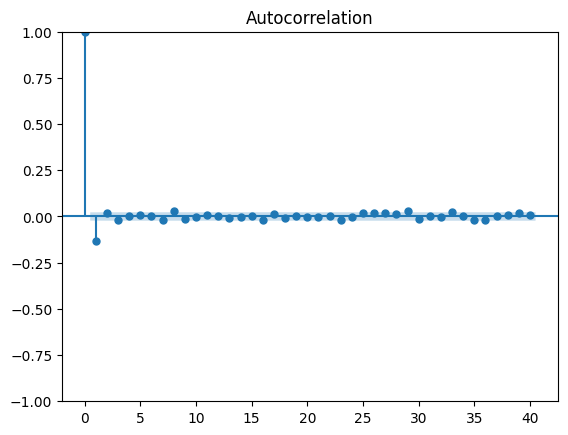

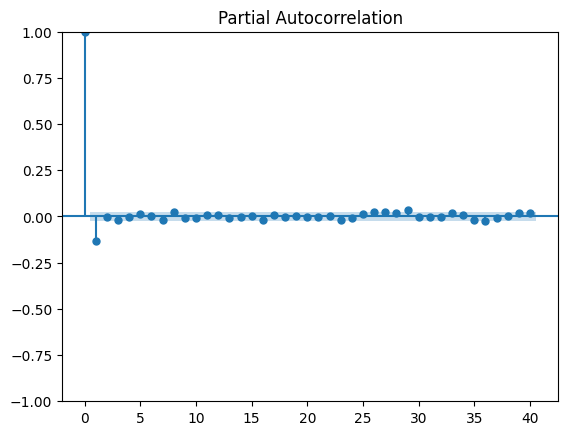

In [15]:
plot_acf(df_diff, lags=40)
plot_pacf(df_diff, lags=40)
plt.show()

### Parameter Selection

* The ADF test confirmed non-stationarity in the original series; therefore, first differencing was applied, resulting in d = 1.

* The ACF plot of the differenced series shows a significant spike at lag 1, with subsequent lags falling within the confidence bounds, indicating a possible MA(1) component.

* The PACF plot does not display a strong autoregressive cutoff pattern beyond lag 1.

This pattern suggests the presence of short-term moving average behavior rather than a strong autoregressive structure. Therefore, ARIMA(0,1,1) was selected as the most appropriate and parsimonious model specification.

### 3. Train-Test Split

In [16]:
train = df['USD_AUD'][:'2009']
test = df['USD_AUD']['2010':]

### 4. ARIMA Model Fitting

In [17]:
model = ARIMA(train, order=(0,1,1))
arima_fit = model.fit()
print(arima_fit.summary())

c:\Users\graj2\Data Science\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\graj2\Data Science\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\graj2\Data Science\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                USD_AUD   No. Observations:                 7305
Model:                 ARIMA(0, 1, 1)   Log Likelihood               26939.509
Date:                Fri, 06 Feb 2026   AIC                         -53875.018
Time:                        23:39:31   BIC                         -53861.226
Sample:                    01-01-1990   HQIC                        -53870.276
                         - 12-31-2009                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.1321      0.002    -63.149      0.000      -0.136      -0.128
sigma2      3.663e-05   1.03e-07    355.412      0.000    3.64e-05    3.68e-05
Ljung-Box (L1) (Q):                   0.00   Jarque-

### 5. ARIMA Diagnostics

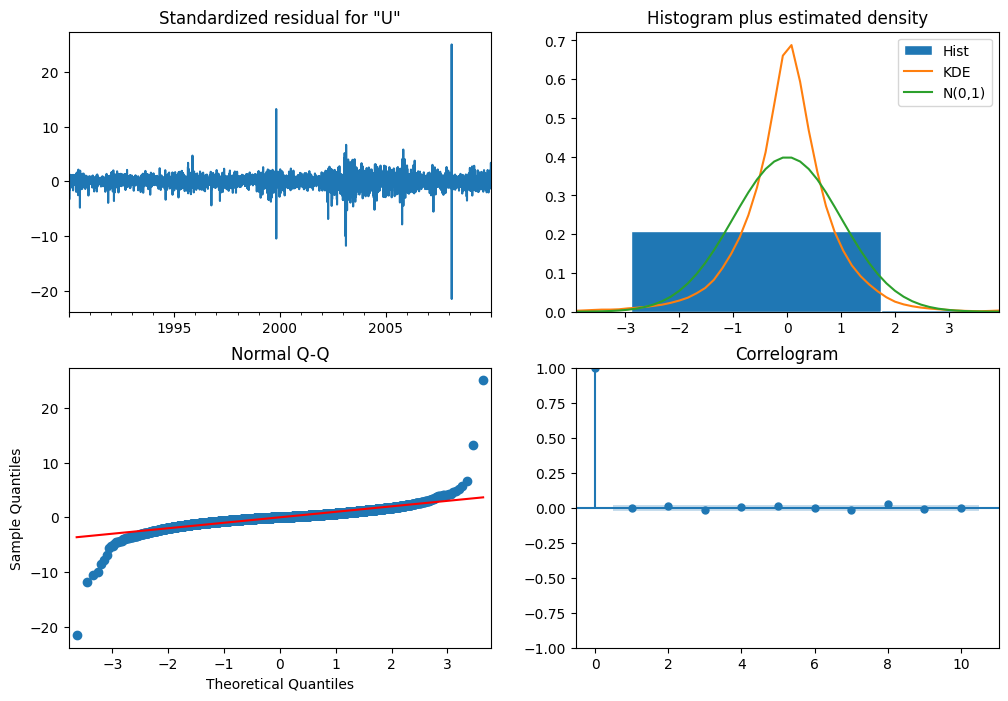

In [18]:
arima_fit.plot_diagnostics(figsize=(12, 8))
plt.show()

In [19]:
lb_test = acorr_ljungbox(arima_fit.resid, lags=[10], return_df=True)
print(lb_test)

     lb_stat  lb_pvalue
10  2.169868   0.994865


In [20]:
arch_test = het_arch(arima_fit.resid)
print("ARCH p-value:", arch_test[1])

ARCH p-value: 0.0


* The residual correlogram indicates no significant autocorrelation, suggesting the ARIMA model has adequately captured the linear dependence structure. However, the histogram and Q-Q plot reveal heavy tails and deviations from normality, which are typical in financial time series data. The residual plot also suggests mild volatility clustering. Overall, despite minor departures from normality, the ARIMA model appears adequate for forecasting purposes.

### 6. ARIMA Forecasting

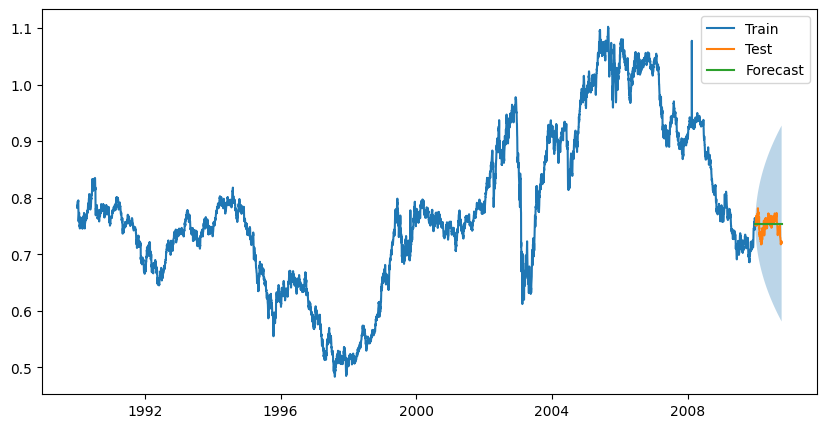

In [21]:
forecast = arima_fit.get_forecast(steps=len(test))
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(test.index, forecast_mean, label='Forecast')

plt.fill_between(test.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 alpha=0.3)

plt.legend()
plt.show()

## Part 3: Exponential Smoothing Model

### 1.Fit Holt’s Model

In [22]:
es_model = ExponentialSmoothing(train, trend='add')
es_fit = es_model.fit()

es_forecast = es_fit.forecast(len(test))

c:\Users\graj2\Data Science\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


### 2. ETS Forecast Visualization

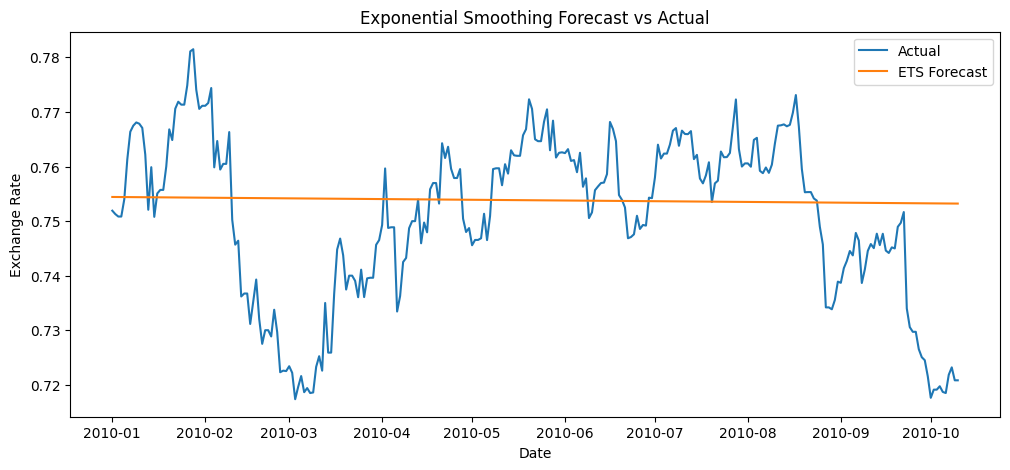

In [23]:
plt.figure(figsize=(12,5))

plt.plot(test.index, test, label='Actual')
plt.plot(test.index, es_forecast, label='ETS Forecast')

plt.title('Exponential Smoothing Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()

plt.show()

* Holt’s linear trend method was applied to model the level and trend components of the exchange rate. The forecast appears relatively smooth, reflecting the model’s focus on capturing long-term structure rather than short-term volatility. This behavior is expected in financial time series exhibiting near-random-walk properties.

## Part 4: Evaluation and Comparison

In [24]:
mae_arima = mean_absolute_error(test, forecast_mean)
rmse_arima = np.sqrt(mean_squared_error(test, forecast_mean))
mape_arima = np.mean(np.abs((test - forecast_mean) / test)) * 100

# ETS Metrics
mae_es = mean_absolute_error(test, es_forecast)
rmse_es = np.sqrt(mean_squared_error(test, es_forecast))
mape_es = np.mean(np.abs((test - es_forecast) / test)) * 100

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)
print("ARIMA MAPE:", mape_arima)

print("ETS MAE:", mae_es)
print("ETS RMSE:", rmse_es)
print("ETS MAPE:", mape_es)

ARIMA MAE: 0.012167538375317545
ARIMA RMSE: 0.01538014552345977
ARIMA MAPE: 1.6375270066293552
ETS MAE: 0.01214842380010227
ETS RMSE: 0.015217374577134912
ETS MAPE: 1.633654836254228


In [25]:
comparison = pd.DataFrame({
    'Model': ['ARIMA', 'Exponential Smoothing'],
    'MAE': [mae_arima, mae_es],
    'RMSE': [rmse_arima, rmse_es],
    'MAPE': [mape_arima, mape_es]
})

comparison

,Model,MAE,RMSE,MAPE
0,ARIMA,0.012168,0.015380,1.637527
1,Exponential Smoothing,0.012148,0.015217,1.633655


Both ARIMA and Exponential Smoothing show similar predictive accuracy. However, ARIMA provides structured modeling of autocorrelation and statistical diagnostics, making it more analytically robust for exchange rate forecasting.

### Conclusion

This study applied ARIMA and Exponential Smoothing models to forecast USD/AUD exchange rates. Both models achieved very similar predictive accuracy, with MAPE values around 1.63%, indicating strong short-term forecasting performance. Exponential Smoothing produced marginally lower MAE and RMSE values; however, the difference between the two models was negligible.

ARIMA provides a more structured modeling framework through explicit treatment of autocorrelation and diagnostic validation, while Exponential Smoothing offers simplicity and comparable accuracy. The near-identical results suggest limited short-term predictability in daily exchange rate movements, consistent with the random-walk characteristics commonly observed in financial time series.